# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. The idea is to discourage overly complex models. If we only minimize MSE, the model might fit the training data extremely closely by using large coefficients, which can lead to overfitting. By adding a penalty that grows with the size of the coefficients, we basically keep the model simple unless bigger coefficients are really necessary. This helps the model generalize better to new data.
2. Regularization lets us control model complexity. When the penalty is small, the model is flexible (low bias, high variance). As we increase the penalty, the model becomes simpler (higher bias, lower variance). By tuning the strength of regularization, we can find a balance where the model isn’t overfitting or underfitting.
3. Ridge regression adds a penalty based on squared coefficients, while LASSO uses the absolute value of coefficients. Because of this, Ridge tends to shrink coefficients toward zero but doesn’t eliminate them completely, while LASSO can force some coefficients to be exactly zero, effectively performing feature selection. So Ridge keeps all variables but shrinks them, while LASSO can simplify the model by removing some variables entirely.
4. We usually standardize variables so they have mean 0 and standard deviation 1. This is important because regularization depends on the size of coefficients. If variables are on different scales, some coefficients would be penalized more than others just because of their units. Scaling makes the penalty fair across all features.
5. It’s usually chosen using cross-validation. We try a range of values for alpha, train models on subsets of the data, and pick the value that gives the lowest validation error. This helps ensure we choose a level of regularization that works well on unseen data.
6. No, we typically evaluate just the regular MSE (without the penalty) because we care about how well the model predicts new data, not how large the coefficients are. The penalty is only used during training to control complexity. For evaluation, we focus on prediction error alone.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

### Case Study #1

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/cars_hw.csv")  # or use your exact filename if needed

# Create Age variable
current_year = 2026
df["Age"] = current_year - df["Make_Year"]

# Features and target
X = df[["Mileage_Run", "Age"]]
y = df["Price"]

# Quick check
X.head()

,Mileage_Run,Age
0,44611,9
1,20305,10
2,29540,7
3,35680,9
4,25126,9


In [3]:
# Polynomial expansion 3rd Degree
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [4]:
# Standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [5]:
# Fit Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


In [6]:
coef_df[coef_df["Feature"] == "Mileage_Run Age"]

,Feature,Coefficient
3,Mileage_Run Age,-1.671212e+06


The interaction between Mileage_Run and Age is negative, which means that as both mileage and age increase together, the predicted price decreases more strongly than either variable alone. 

In [7]:
from sklearn.linear_model import LassoCV

# Grid of alpha values to search over
alphas = np.logspace(1, 3, 20)

# Fit Lasso with 20-fold cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=42)
lasso_cv.fit(X_scaled, y)

# Best alpha selected by cross-validation
print("Best alpha:", lasso_cv.alpha_)

# Coefficients
lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv.coef_
})

lasso_coef_df

Best alpha: 88.58667904100822


,Feature,Coefficient
0,Mileage_Run,7.790762e+05
1,Age,-1.339534e+05
2,Mileage_Run^2,-2.015634e+05
3,Mileage_Run Age,-1.322419e+06
4,Age^2,0.000000e+00
5,Mileage_Run^3,-4.240952e+04
6,Mileage_Run^2 Age,2.715062e+05
7,Mileage_Run Age^2,5.415432e+05
8,Age^3,1.374220e+04


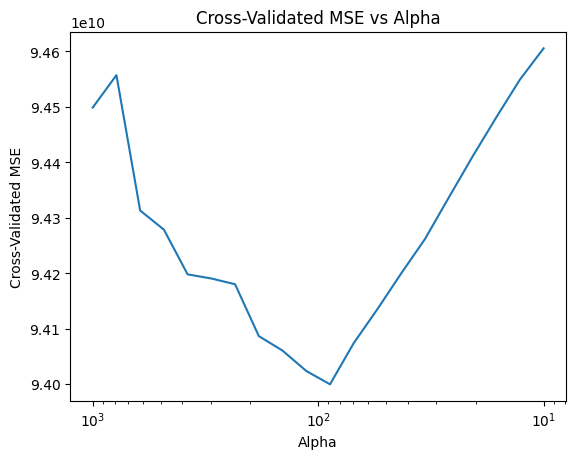

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Mean MSE across folds
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE vs Alpha")
plt.gca().invert_xaxis() 
plt.show()

In [9]:
from sklearn.linear_model import Lasso

alphas = np.logspace(1, 3, 50)  # smoother curve
coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

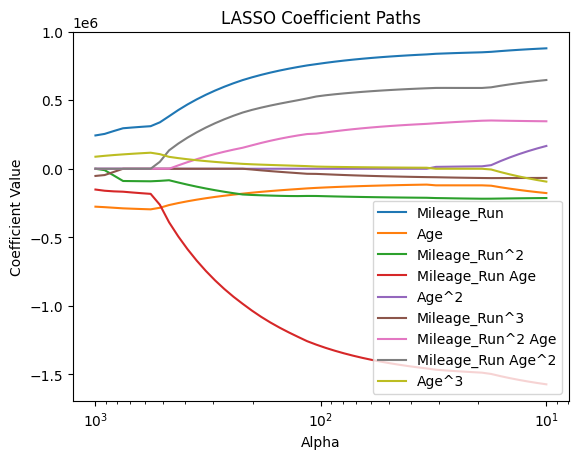

In [13]:
plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.legend()

plt.show()

In [14]:
# Get coefficients from LassoCV
lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv.coef_
})

# Features selected (non-zero coefficients)
selected_features = lasso_coef_df[lasso_coef_df["Coefficient"] != 0]

# Features set to zero
zero_features = lasso_coef_df[lasso_coef_df["Coefficient"] == 0]

# Proportion set to zero
prop_zero = len(zero_features) / len(lasso_coef_df)

print("Selected features:")
print(selected_features)

print("\nNumber of features set to zero:", len(zero_features))
print("Total number of features:", len(lasso_coef_df))
print("Proportion set to zero:", prop_zero)

Selected features:
             Feature   Coefficient
0        Mileage_Run  7.790762e+05
1                Age -1.339534e+05
2      Mileage_Run^2 -2.015634e+05
3    Mileage_Run Age -1.322419e+06
5      Mileage_Run^3 -4.240952e+04
6  Mileage_Run^2 Age  2.715062e+05
7  Mileage_Run Age^2  5.415432e+05
8              Age^3  1.374220e+04

Number of features set to zero: 1
Total number of features: 9
Proportion set to zero: 0.1111111111111111


The features selected by LASSO (those with non-zero coefficients) include Mileage_Run, Age, Mileage_Run², the interaction term Mileage_Run × Age, and higher-order polynomial terms such as Mileage_Run³, Mileage_Run² × Age, Mileage_Run × Age², and Age³.

Only 1 feature was set equal to zero, meaning approximately 11.1% of the coefficients were eliminated.

Compared to the original linear regression, the LASSO-regularized coefficients are generally smaller in magnitude due to the penalty shrinking the coefficients toward zero. For example, the coefficient for Mileage_Run decreased from 9.12E5 in the linear model to 7.79E5 in the LASSO model. This reflects the goal of regularization to reduce model complexity and prevent overfitting. Most coefficients decreased in magnitude after applying LASSO, and only one coefficient was driven exactly to zero. However, a few coefficients slightly increased in magnitude after regularization, such as the Age2 and Age3 terms. This indicates that LASSO can redistribute weight among correlated features rather than uniformly shrinking all coefficients. Some coefficients like the Age2 and Age 3 changed signs. This suggests that regularization altered the contribution of certain higher-order terms. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

### Case Study #2

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

In [17]:
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [18]:
# Continuous variables for polynomial expansion
X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]

# Dummy/categorical variables for interaction terms
X_cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

# Response variable
y = df["DEATH_EVENT"]

In [22]:
# Create 3rd degree polynomial features for continuous variables
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

cont_feature_names = poly_cont.get_feature_names_out(
    ["age", "ejection_fraction", "serum_creatinine"]
)

print(cont_feature_names)
print("Number of continuous polynomial features:", len(cont_feature_names))

['age' 'ejection_fraction' 'serum_creatinine' 'age^2'
 'age ejection_fraction' 'age serum_creatinine' 'ejection_fraction^2'
 'ejection_fraction serum_creatinine' 'serum_creatinine^2' 'age^3'
 'age^2 ejection_fraction' 'age^2 serum_creatinine'
 'age ejection_fraction^2' 'age ejection_fraction serum_creatinine'
 'age serum_creatinine^2' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine'
 'ejection_fraction serum_creatinine^2' 'serum_creatinine^3']
Number of continuous polynomial features: 19


In [23]:
# Standardize the continuous polynomial features
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

In [24]:
# Create interaction
poly_cat = PolynomialFeatures(degree=4, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

cat_feature_names = poly_cat.get_feature_names_out(
    ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
)

print(cat_feature_names)
print("Number of categorical interaction features:", len(cat_feature_names))

['anaemia' 'diabetes' 'high_blood_pressure' 'smoking' 'anaemia diabetes'
 'anaemia high_blood_pressure' 'anaemia smoking'
 'diabetes high_blood_pressure' 'diabetes smoking'
 'high_blood_pressure smoking' 'anaemia diabetes high_blood_pressure'
 'anaemia diabetes smoking' 'anaemia high_blood_pressure smoking'
 'diabetes high_blood_pressure smoking'
 'anaemia diabetes high_blood_pressure smoking']
Number of categorical interaction features: 15


In [25]:
# Concatenate the continuous and categorical features
X_final = np.hstack([X_cont_scaled, X_cat_inter])
all_feature_names = np.concatenate([cont_feature_names, cat_feature_names])

X_final_df = pd.DataFrame(X_final, columns=all_feature_names)
X_final_df.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking,anaemia diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Run linear regression
lin_model = LinearRegression()
lin_model.fit(X_final, y)

lin_coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Linear_Coefficient": lin_model.coef_
})

lin_coef_df

,Feature,Linear_Coefficient
0,age,1.619432
1,ejection_fraction,-2.062277
2,serum_creatinine,-0.757092
3,age^2,-3.717758
4,age ejection_fraction,-0.800726
5,age serum_creatinine,1.707056
6,ejection_fraction^2,3.352956
7,ejection_fraction serum_creatinine,2.569764
8,serum_creatinine^2,-2.640240
9,age^3,1.963124


Yes, some sign patterns appear counterintuitive. For example, serum_creatinine has a negative coefficient even though higher values are typically associated with worse outcomes, and age has both positive and negative terms (age vs. age²).

This occurs because the model includes higher-order and interaction terms, so each variable’s effect is not captured by a single coefficient. The inclusion of these terms allows the model to capture nonlinear relationships and interactions between variables, meaning the overall effect can still make sense even if individual coefficients appear contradictory.

In [27]:
# Fit LassoCV with 20 fold cross-validation
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    max_iter=100000,
    random_state=42
)

lasso_cv.fit(X_final, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005736152510448681


In [28]:
lasso_coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Lasso_Coefficient": lasso_cv.coef_
})

lasso_coef_df

,Feature,Lasso_Coefficient
0,age,-0.000000
1,ejection_fraction,-0.329656
2,serum_creatinine,0.116875
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.117992


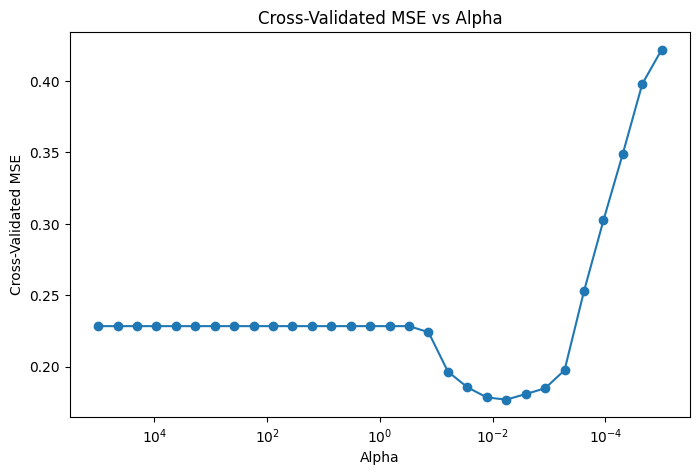

In [29]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mean_mse, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE vs Alpha")
plt.gca().invert_xaxis()
plt.show()

In [30]:
alpha_grid = np.logspace(-5, 5, 100)
coef_paths = []

for a in alpha_grid:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_final, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

/opt/anaconda3/envs/BME2315/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.087e-03, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(


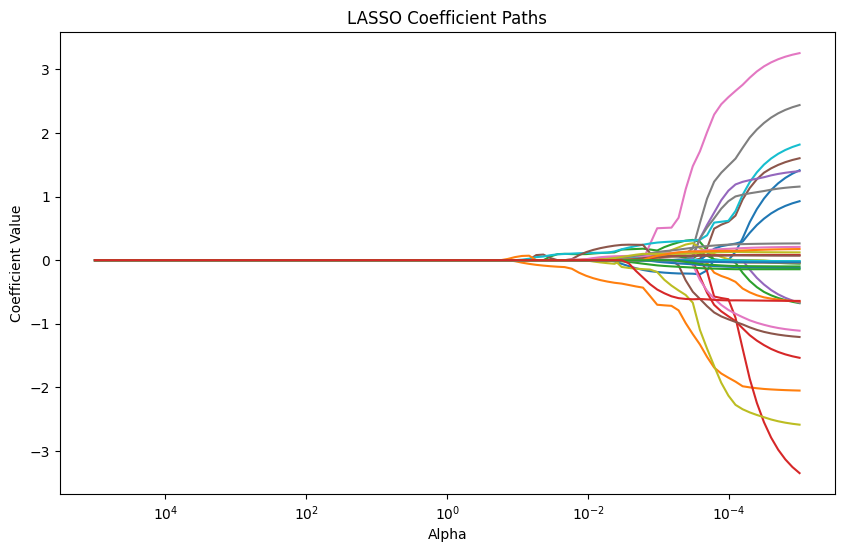

In [31]:
plt.figure(figsize=(10, 6))

for i in range(coef_paths.shape[1]):
    plt.plot(alpha_grid, coef_paths[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

In [32]:
selected_features = lasso_coef_df[lasso_coef_df["Lasso_Coefficient"] != 0]
zero_features = lasso_coef_df[lasso_coef_df["Lasso_Coefficient"] == 0]

prop_zero = len(zero_features) / len(lasso_coef_df)

print("Selected features:")
print(selected_features)

print("\nNumber of features set to zero:", len(zero_features))
print("Total number of features:", len(lasso_coef_df))
print("Proportion set to zero:", prop_zero)

Selected features:
                                 Feature  Lasso_Coefficient
1                      ejection_fraction          -0.329656
2                       serum_creatinine           0.116875
9                                  age^3           0.117992
15                   ejection_fraction^3           0.204822
16  ejection_fraction^2 serum_creatinine           0.032801
18                    serum_creatinine^3          -0.043266
19                               anaemia           0.014178
20                              diabetes           0.000607
21                   high_blood_pressure           0.013608
26          diabetes high_blood_pressure           0.053968
27                      diabetes smoking           0.003466
28           high_blood_pressure smoking           0.017805

Number of features set to zero: 22
Total number of features: 34
Proportion set to zero: 0.6470588235294118


In [33]:
compare_df = lin_coef_df.merge(lasso_coef_df, on="Feature")

compare_df["Abs_Linear"] = compare_df["Linear_Coefficient"].abs()
compare_df["Abs_Lasso"] = compare_df["Lasso_Coefficient"].abs()

compare_df["Increased_in_Magnitude"] = compare_df["Abs_Lasso"] > compare_df["Abs_Linear"]
compare_df["Sign_Changed"] = np.sign(compare_df["Linear_Coefficient"]) != np.sign(compare_df["Lasso_Coefficient"])

compare_df

,Feature,Linear_Coefficient,Lasso_Coefficient,Abs_Linear,Abs_Lasso,Increased_in_Magnitude,Sign_Changed
0,age,1.619432,-0.000000,1.619432,0.000000,False,True
1,ejection_fraction,-2.062277,-0.329656,2.062277,0.329656,False,False
2,serum_creatinine,-0.757092,0.116875,0.757092,0.116875,False,True
3,age^2,-3.717758,0.000000,3.717758,0.000000,False,True
4,age ejection_fraction,-0.800726,-0.000000,0.800726,0.000000,False,True
5,age serum_creatinine,1.707056,0.000000,1.707056,0.000000,False,True
6,ejection_fraction^2,3.352956,0.000000,3.352956,0.000000,False,True
7,ejection_fraction serum_creatinine,2.569764,0.000000,2.569764,0.000000,False,True
8,serum_creatinine^2,-2.640240,-0.000000,2.640240,0.000000,False,True
9,age^3,1.963124,0.117992,1.963124,0.117992,False,False


The features selected by LASSO (non-zero coefficients) include ejection_fraction, serum_creatinine, age³, ejection_fraction³, ejection_fraction² × serum_creatinine, serum_creatinine³, anaemia, diabetes, high_blood_pressure, and a few interaction terms such as diabetes × high_blood_pressure, diabetes × smoking, and high_blood_pressure × smoking. Out of 34 total features, 22 were set to zero, meaning approximately 64.7% of the coefficients were eliminated. 

Compared to the linear regression, most coefficients decreased in magnitude due to the shrinkage effect of LASSO, and no coefficients meaningfully increased in magnitude. However, several coefficients changed sign (for example, serum_creatinine changed from negative to positive, and anaemia from negative to positive), reflecting how regularization redistributes importance among correlated features.

The sign patterns from the LASSO model generally make more sense because the model is simpler and less affected by instability from highly correlated polynomial and interaction terms. From a bias-variance perspective, the original linear model has low bias but high variance due to its complexity, leading to unstable and potentially misleading coefficients. LASSO introduces some bias by shrinking coefficients toward zero, but it reduces variance, resulting in a more stable and interpretable model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. 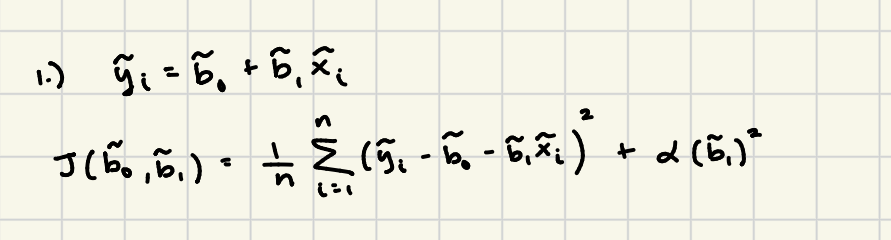
2. 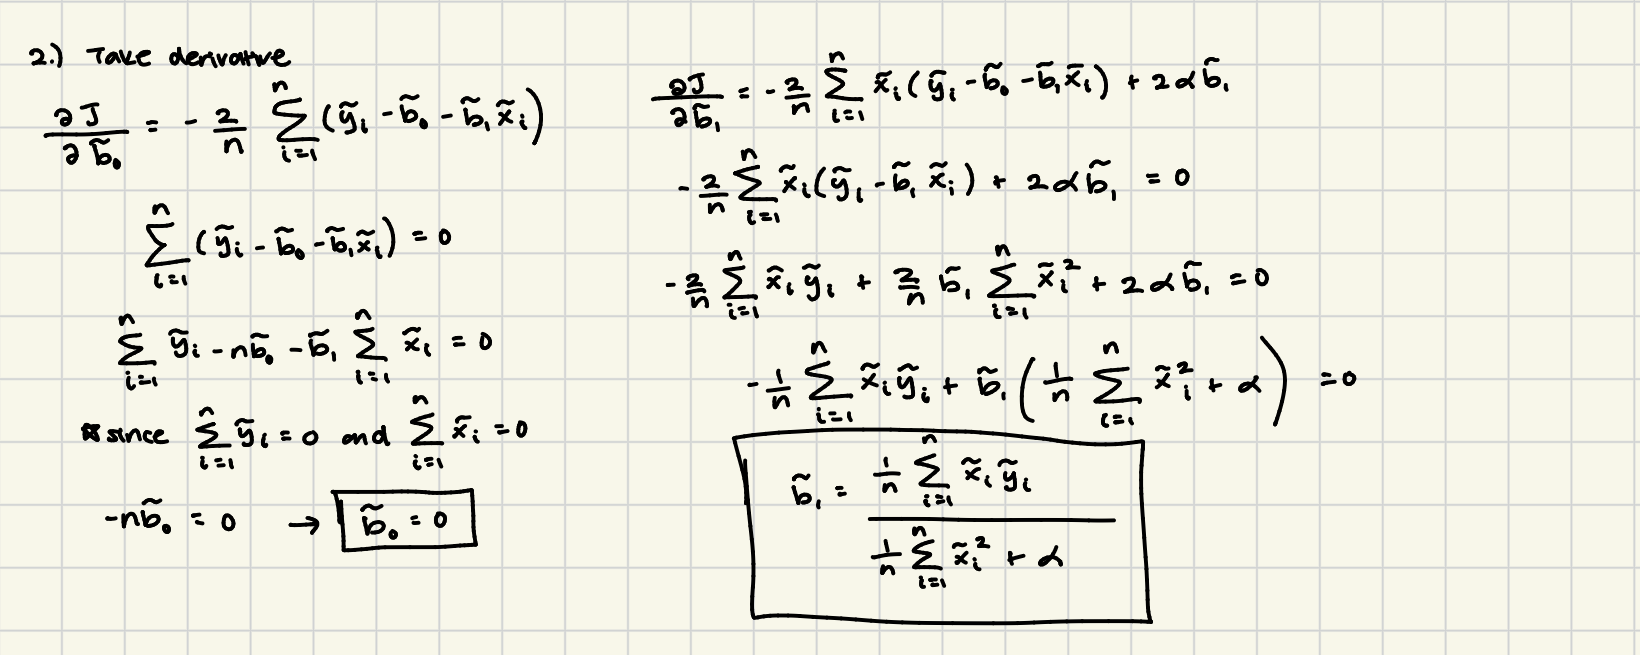
3. As alpha increases, the denominator gets larger, so the slope coefficient shrinks toward zero.
4. The main challenge is that the absolute value function is not differentiable at b1=0. You can't take the derivative everywhere and solve one smooth equation. It is optimal to set b1=0 when the correlation between x and y is not large enough to overcome the penalty. 
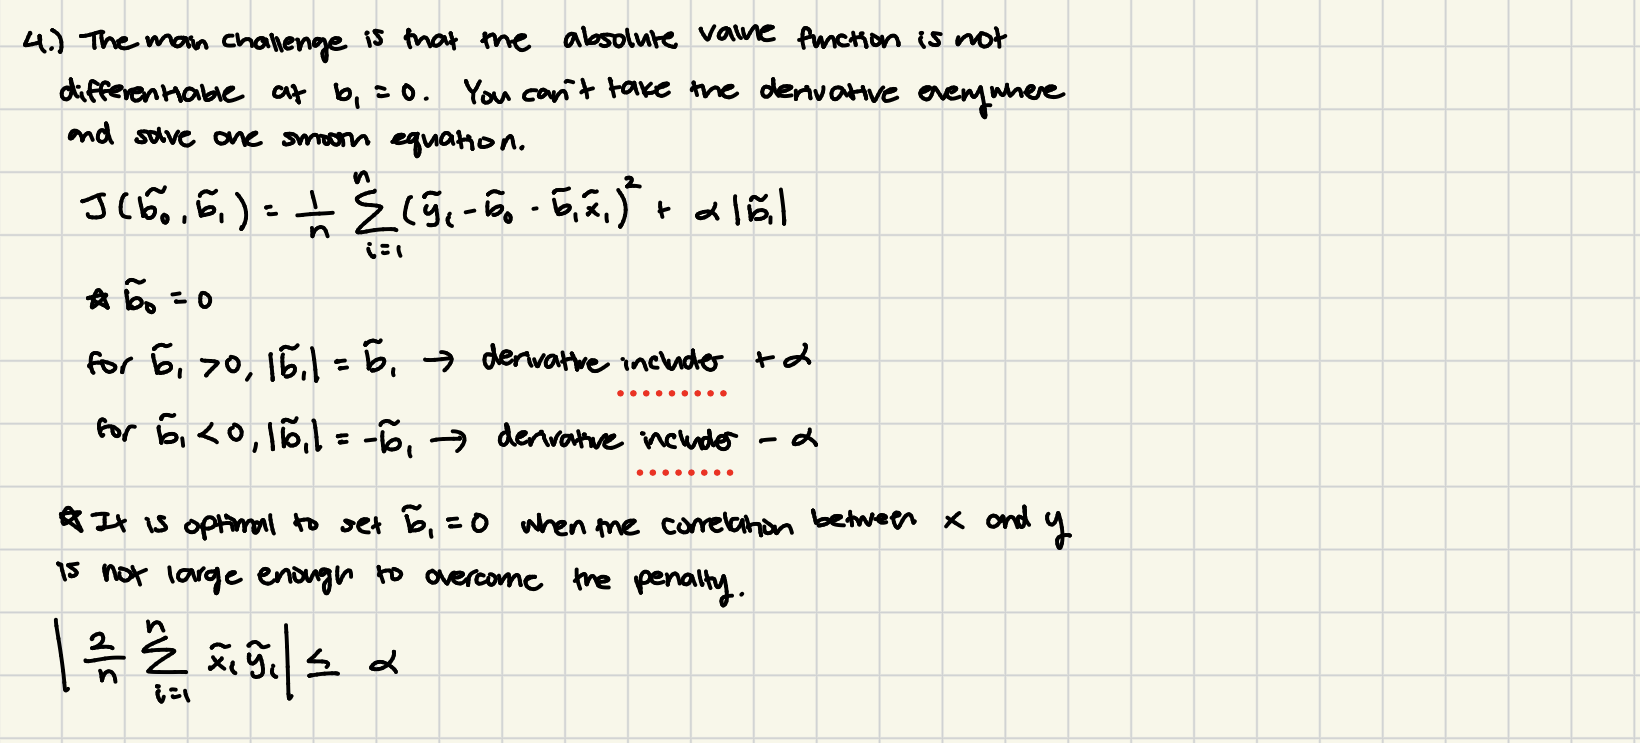